# RoBERTa + Label-Dependency 


## 0. Kiểm tra GPU 

In [1]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"✅ Dùng GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  KHÔNG CÓ GPU — train sẽ rất chậm, cân nhắc chuyển sang Colab trước khi chạy tiếp.")
DEVICE

✅ Dùng GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition MIG 1g.24gb


'cuda'

In [2]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from toxic_comments.config import (
    HEAVY_TEXT_COLUMN,
    K_FOLD_DATA_DIR,
    LABEL_COLUMNS,
    MODELS_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_DIR,
)
from toxic_comments.splits import save_kfold_datasets
from toxic_comments.train import train_from_folds
from toxic_comments.evaluation import summarize_folds

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /root/AI4SE_toxic_comments


## 1. Load data đã clean sẵn

In [3]:
data_path = PROCESSED_DATA_DIR / "train_clean.csv"
data = pd.read_csv(data_path)
print("Số dòng:", len(data))
data[[HEAVY_TEXT_COLUMN, *LABEL_COLUMNS]].head(3)

Số dòng: 159476


,comment_heavy,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why edits made username hardcore m...,0,0,0,0,0,0
1,aww matches background colour seemingly stuck ...,0,0,0,0,0,0
2,hey man really not trying edit war just guy co...,0,0,0,0,0,0


In [4]:
written = save_kfold_datasets(
    data=data,
    output_dir=K_FOLD_DATA_DIR,
    n_splits=5,
    random_state=42,
    text_column=HEAVY_TEXT_COLUMN,
    strategy="stratified",
)
print(f"Đã ghi {len(written)} file vào {K_FOLD_DATA_DIR}")

Đã ghi 10 file vào /root/AI4SE_toxic_comments/data/k_fold


## 3. Train `roberta_label_dependency` trên từng fold



In [5]:
MODEL_NAME = "roberta_label_dependency"

model_paths, fold_metrics = train_from_folds(
    folds_dir=K_FOLD_DATA_DIR,
    model_name=MODEL_NAME,
    output_dir=MODELS_DIR,
    results_dir=RESULTS_DIR,
    text_column=HEAVY_TEXT_COLUMN,
)
print(f"Đã lưu {len(model_paths)} model:")
for path in model_paths:
    print(" ", path)

/root/AI4SE_toxic_comments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7876.36it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on y

Đang tokenize 127,580 dòng...
Tokenize xong sau 13.1s — bắt đầu train.


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10167.07it/s]      
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang tokenize 127,581 dòng...
Tokenize xong sau 13.4s — bắt đầu train.


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10766.26it/s]      
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12071.26it/s]      
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang tokenize 127,581 dòng...
Tokenize xong sau 13.2s — bắt đầu train.


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10061.22it/s]      
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang tokenize 127,581 dòng...
Tokenize xong sau 13.3s — bắt đầu train.


Đã lưu 5 model:
  /root/AI4SE_toxic_comments/models/fold_1/roberta_label_dependency.joblib
  /root/AI4SE_toxic_comments/models/fold_2/roberta_label_dependency.joblib
  /root/AI4SE_toxic_comments/models/fold_3/roberta_label_dependency.joblib
  /root/AI4SE_toxic_comments/models/fold_4/roberta_label_dependency.joblib
  /root/AI4SE_toxic_comments/models/fold_5/roberta_label_dependency.joblib


## 4. Kết quả 

In [6]:
fold_metrics

,model_name,fold,split,rows,subset_accuracy,hamming_loss,micro_precision,micro_recall,micro_f1,macro_f1,micro_roc_auc,macro_roc_auc
0,roberta_label_dependency,fold_1,test,31896,0.921338,0.016643,0.764293,0.790088,0.776976,0.639883,0.991930,0.988605
1,roberta_label_dependency,fold_2,test,31895,0.924910,0.016047,0.785869,0.773219,0.779493,0.638159,0.991258,0.987688
2,roberta_label_dependency,fold_3,test,31895,0.920991,0.016617,0.765210,0.788769,0.776811,0.597861,0.991395,0.989140
3,roberta_label_dependency,fold_4,test,31895,0.921618,0.016831,0.758941,0.792587,0.775399,0.620637,0.991367,0.988754
4,roberta_label_dependency,fold_5,test,31895,0.920834,0.016967,0.780158,0.747790,0.763631,0.597890,0.989795,0.986433


In [7]:
summary = summarize_folds(fold_metrics, group_by="model_name")
# Chỉ hiện 2 metric chính cho gọn — bỏ dòng dưới nếu muốn xem tất cả
key_metrics = ["macro_f1", "micro_roc_auc", "macro_roc_auc"]
summary[[c for c in summary.columns if c[0] in key_metrics]]

macro_f1         macro_roc_auc         micro_roc_auc  \
                             mean     std          mean     std          mean   
model_name                                                                      
roberta_label_dependency   0.6189  0.0206        0.9881  0.0011        0.9911   

                                  
                             std  
model_name                        
roberta_label_dependency  0.0008

In [8]:
summary = summarize_folds(fold_metrics, group_by="model_name")
key_metrics = ["micro_f1", "macro_f1", "micro_roc_auc", "macro_roc_auc"]
summary = summary[[c for c in summary.columns if c[0] in key_metrics]]
summary

macro_f1         macro_roc_auc         micro_f1  \
                             mean     std          mean     std     mean   
model_name                                                                 
roberta_label_dependency   0.6189  0.0206        0.9881  0.0011   0.7745   

                                 micro_roc_auc          
                             std          mean     std  
model_name                                              
roberta_label_dependency  0.0062        0.9911  0.0008

## 5. Biểu đồ Macro-F1 và ROC-AUC qua các fold

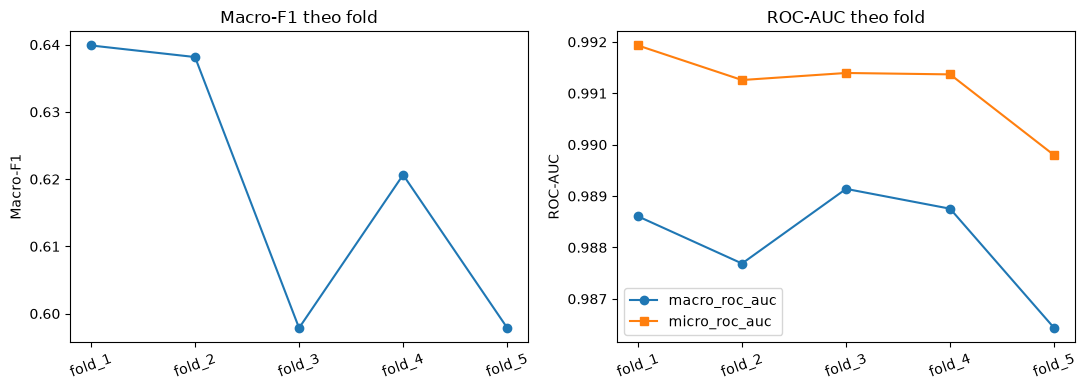

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(fold_metrics["fold"], fold_metrics["macro_f1"], marker="o")
axes[0].set_title("Macro-F1 theo fold")
axes[0].set_ylabel("Macro-F1")
axes[0].tick_params(axis="x", rotation=20)

axes[1].plot(fold_metrics["fold"], fold_metrics["macro_roc_auc"], marker="o", label="macro_roc_auc")
axes[1].plot(fold_metrics["fold"], fold_metrics["micro_roc_auc"], marker="s", label="micro_roc_auc")
axes[1].set_title("ROC-AUC theo fold")
axes[1].set_ylabel("ROC-AUC")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

fig.tight_layout()
plt.show()

## 6. Kết quả từng nhãn



In [10]:
per_label_path = RESULTS_DIR / f"{MODEL_NAME}_fold_per_label.csv"
per_label = pd.read_csv(per_label_path)

per_label_summary = (
    per_label.groupby("label")[["f1", "roc_auc", "support"]]
    .agg(["mean", "std"])
    .round(4)
)
per_label_summary

f1         roc_auc         support        
                 mean     std    mean     std    mean     std
label                                                        
identity_hate  0.5016  0.0903  0.9887  0.0017   281.0  1.4142
insult         0.7474  0.0211  0.9874  0.0013  1574.8  1.4832
obscene        0.8381  0.0100  0.9936  0.0009  1689.2  1.6432
severe_toxic   0.3831  0.1082  0.9904  0.0010   318.8  1.4832
threat         0.4256  0.0494  0.9853  0.0041    95.6  1.1402
toxic          0.8175  0.0047  0.9833  0.0009  3058.0  1.4142

In [14]:
per_label_path = RESULTS_DIR / f"{MODEL_NAME}_fold_per_label.csv"
per_label = pd.read_csv(per_label_path)

print("### F1 PER LABEL (mean ± std over 5 folds)")
per_label_summary = (
    per_label.groupby(["model_name", "label"])["f1"]
    .agg(["mean", "std"])
    .round(4)
)
per_label_summary

### F1 PER LABEL (mean ± std over 5 folds)


mean     std
model_name               label                        
roberta_label_dependency identity_hate  0.5016  0.0903
                         insult         0.7474  0.0211
                         obscene        0.8381  0.0100
                         severe_toxic   0.3831  0.1082
                         threat         0.4256  0.0494
                         toxic          0.8175  0.0047

In [12]:
import joblib

from toxic_comments.cleaning import clean_light, clean_heavy

model_path = MODELS_DIR / "fold_1" / f"{MODEL_NAME}.joblib"
loaded_model = joblib.load(model_path)
print("Đã load:", model_path)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8153.28it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đã load: /root/AI4SE_toxic_comments/models/fold_1/roberta_label_dependency.joblib


In [13]:
new_comments = [
    "You are such an idiot, I hope something bad happens to you.",
    "Thanks so much for fixing this, really appreciate it!",
]

cleaned = pd.Series(new_comments).apply(clean_light).apply(clean_heavy)
scores = loaded_model.predict_proba(cleaned)
preds = (scores >= 0.5).astype(int)

result = pd.DataFrame({"comment_text": new_comments})
for i, label in enumerate(LABEL_COLUMNS):
    result[f"{label}_prob"] = scores[:, i].round(4)
    result[f"{label}_pred"] = preds[:, i]

pd.set_option("display.max_colwidth", 40)
result

,comment_text,toxic_prob,toxic_pred,severe_toxic_prob,severe_toxic_pred,obscene_prob,obscene_pred,threat_prob,threat_pred,insult_prob,insult_pred,identity_hate_prob,identity_hate_pred
0,"You are such an idiot, I hope someth...",0.9845,1,0.0532,0,0.4441,0,0.0705,0,0.9160,1,0.0211,0
1,"Thanks so much for fixing this, real...",0.0006,0,0.0000,0,0.0001,0,0.0000,0,0.0001,0,0.0000,0
